### Additional EDA

In [18]:
import pickle
from typing import DefaultDict
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
with open('../../data/movies_df.pkl', 'rb') as f:
    movies_df = pickle.load(f)

In [3]:
movies_df.head()

,id,title,description,summary,image,url,datePublished,duration,genre,keywords,aggregateRating,actors,directors,creators,trailer,review,text
0,tt1649444,[Rec]³: Génesis,A couple&apos;s wedding day turns horrific as ...,,https://m.media-amazon.com/images/M/MV5BNDM3OT...,https://www.imdb.com/title/tt1649444/,2012-04-20,PT1H20M,"[Action, Adventure, Fantasy]","wedding,infection,third part,death of protagon...","{'@type': 'AggregateRating', 'ratingCount': 40...",[],[],"[{'name': None, 'url': 'https://www.imdb.com/c...","{'name': 'Tráiler [OV]', 'url': 'https://www.i...","{'@type': 'Review', 'itemReviewed': {'@type': ...",A couple&apos;s wedding day turns horrific as ...
1,tt28015403,Heretic,Two young religious women are drawn into a gam...,Reviewers say 'Heretic' is a thought-provoking...,https://m.media-amazon.com/images/M/MV5BMTI1ZT...,https://www.imdb.com/title/tt28015403/,2024-11-22,PT1H51M,"[Horror, Thriller]","mormon,psychological horror,religion,atheist,s...","{'@type': 'AggregateRating', 'ratingCount': 20...",[],[],"[{'name': None, 'url': 'https://www.imdb.com/c...","{'name': 'Final Trailer', 'url': 'https://www....","{'@type': 'Review', 'itemReviewed': {'@type': ...",Two young religious women are drawn into a gam...
2,tt0317219,Cars,"On the way to the biggest race of his life, a ...",,https://m.media-amazon.com/images/M/MV5BMTg5Nz...,https://www.imdb.com/title/tt0317219/,2006-07-23,PT1H56M,"[Animation, Adventure, Comedy]","car,car movie,arrogance,bad guy wins,spit take","{'@type': 'AggregateRating', 'ratingCount': 51...",[],[],"[{'name': None, 'url': 'https://www.imdb.com/c...",{'name': 'How the Best Racing Films Raise the ...,"{'@type': 'Review', 'itemReviewed': {'@type': ...","On the way to the biggest race of his life, a ..."
3,tt0187078,Gone in Sixty Seconds,"To save his brother, ex-thief Memphis must ste...",,https://m.media-amazon.com/images/M/MV5BNzEyND...,https://www.imdb.com/title/tt0187078/,2000-06-30,PT1H58M,"[Action, Crime, Thriller]","car theft,exploding car,explosion,fight,former...","{'@type': 'AggregateRating', 'ratingCount': 30...",[],[],"[{'name': None, 'url': 'https://www.imdb.com/c...","{'name': 'Trailer', 'url': 'https://www.imdb.c...","{'@type': 'Review', 'itemReviewed': {'@type': ...","To save his brother, ex-thief Memphis must ste..."
4,tt0082118,The Burning,"Abusive former summer camp caretaker Cropsy, h...",,https://m.media-amazon.com/images/M/MV5BMzA1Nz...,https://www.imdb.com/title/tt0082118/,1981-05-08,PT1H31M,[Horror],"summer camp,teen horror,male orgasm,bare chest...","{'@type': 'AggregateRating', 'ratingCount': 24...",[],[],"[{'name': None, 'url': 'https://www.imdb.com/c...","{'name': 'The Burning', 'url': 'https://www.im...","{'@type': 'Review', 'itemReviewed': {'@type': ...","Abusive former summer camp caretaker Cropsy, h..."


#### Check amount of unique genres

In [15]:
genre_counter = DefaultDict(int)

for row in movies_df.itertuples():
    genres = row.genre
    for genre in genres:
        genre_counter[genre] += 1

In [16]:
genre_counter = {k: v for k, v in sorted(genre_counter.items(), key=lambda item: item[1], reverse=True)}

genre_counter

{'Drama': 5589,
 'Comedy': 3648,
 'Action': 2605,
 'Crime': 2103,
 'Adventure': 1726,
 'Thriller': 1711,
 'Romance': 1643,
 'Horror': 1309,
 'Mystery': 1162,
 'Biography': 752,
 'Fantasy': 751,
 'Sci-Fi': 700,
 'Animation': 508,
 'Family': 474,
 'History': 363,
 'Music': 297,
 'Sport': 232,
 'Documentary': 205,
 'War': 176,
 'Musical': 100,
 'Western': 49,
 'News': 3,
 'Adult': 1}

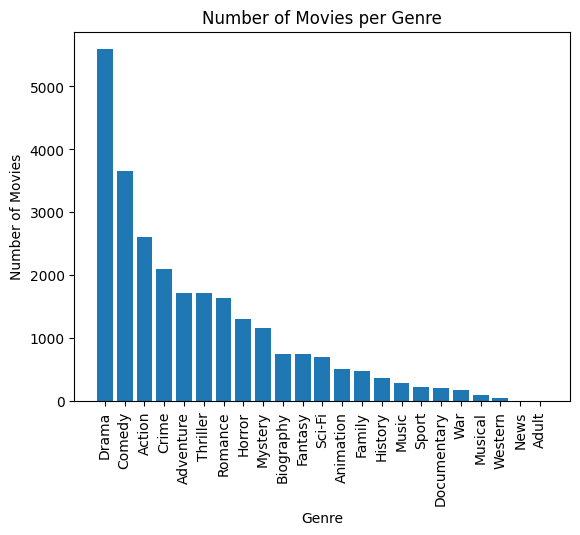

In [21]:
plt.bar(genre_counter.keys(), genre_counter.values())
plt.xticks(rotation=90)
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.title('Number of Movies per Genre')
plt.show()

Check how many of the movies have at least one of the three most popular: Drama, Comedy, Action

In [24]:
popular_genres = ['Drama', 'Comedy', 'Action']
popular_counter = {"yes": 0, "no": 0}

for row in movies_df.itertuples():
    genres = row.genre
    if any(genre in popular_genres for genre in genres):
        popular_counter["yes"] += 1
    else:
        popular_counter["no"] += 1

popular_counter

{'yes': 8947, 'no': 1053}

In [25]:
print(f"Movies with at least one popular genre: {popular_counter['yes']}")
print(f"Movies with no popular genres: {popular_counter['no']}")

Movies with at least one popular genre: 8947
Movies with no popular genres: 1053


With this output we can safely use only three main genres and rest change to new category: 'Other'.